In [1]:
from core.utils import *
import os
from core.datasetclass import *
from core.model import TensorBasisGPModel, SVTBGPModel
import jax
import jax.numpy as jnp
import numpy as np
# Enable Float64 for more stable matrix inversions.
from jax import config
import jax.numpy as jnp
import jax.random as jr
from jaxtyping import install_import_hook
import matplotlib as mpl
import matplotlib.pyplot as plt
from core.material_models import get_material
from sklearn.preprocessing import StandardScaler, MinMaxScaler
config.update("jax_enable_x64", True)

import datetime
# with install_import_hook("gpjax", "beartype.beartype"):
#     import gpjax as gpx
import gpjax as gpx

key = jr.key(123)

/dolfinx-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
dataset = BenchmarkDataset("dataset/benchmarks", "noise=low", "Isihara")
loadsteps = dataset.loadsteps[:]
F_list = []
invariants_list = []
sigma_list = []
coeffs_list = []
piola_list = []
for i in loadsteps :
    data = dataset[i]
    f = data["F"]
    invariants = data["invariants"]
    sigma = data["sigma"]
    coeffs = data["coeffs"]
    piola = data["P"]
    F_list.append(f)
    invariants_list.append(invariants)
    coeffs_list.append(coeffs)
    sigma_list.append(sigma)
    piola_list.append(piola)

F_train = jnp.concat(F_list)
invariants_train = jnp.concat(invariants_list)
sigma_train = jnp.concat(sigma_list)
coeffs_train = jnp.concat(coeffs_list)
piola_train = jnp.concat(piola_list)

['10', '100', '15', '20', '25', '30', '35', '40', '45', '5', '50', '55', '60', '65', '70', '75', '80', '85', '90', '95']


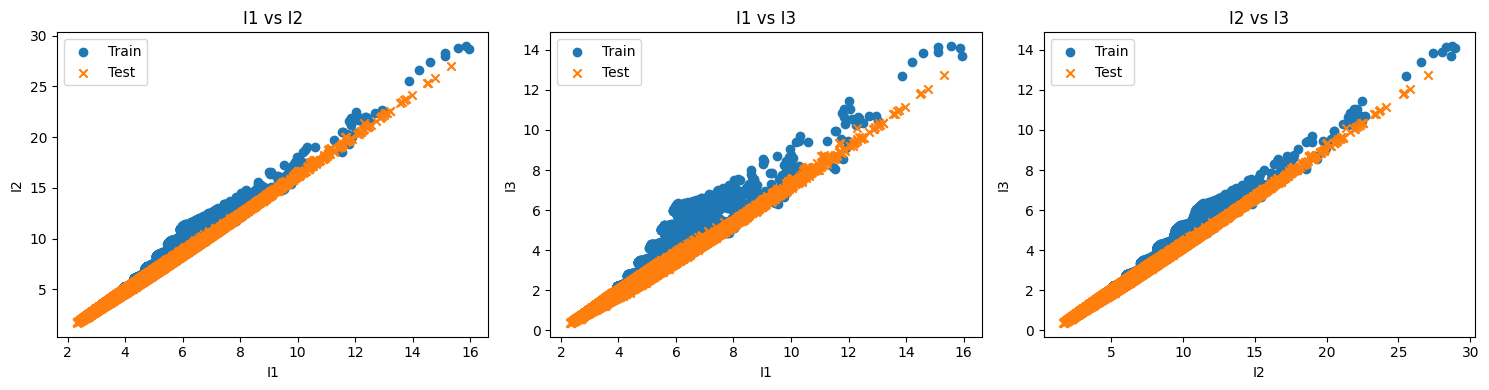

In [36]:
dataset = TestSpecimen("dataset/benchmarks/test-specimen", "Isihara-GT")
step = 4
loadsteps = dataset.loadsteps[:]
F_list = []
invariants_list = []
sigma_list = []
coeffs_list = []
piola_list = []
print(loadsteps)
for i in loadsteps :
    data = dataset[i]
    f = data["F"]
    invariants = data["invariants"]
    sigma = data["sigma"]
    coeffs = data["coeffs"]
    piola = data["P"]
    F_list.append(f)
    invariants_list.append(invariants)
    coeffs_list.append(coeffs)
    sigma_list.append(sigma)
    piola_list.append(piola)

F_test = jnp.concat(F_list)
invariants_test = jnp.concat(invariants_list)
sigma_train = jnp.concat(sigma_list)
coeffs_train = jnp.concat(coeffs_list)
piola_train = jnp.concat(piola_list)
import numpy as np
import matplotlib.pyplot as plt

# Try loading user's arrays; create placeholders if missing
# I1_train, I2_train, I3_train = inv_train[:,2]**(-1/3) * inv_train[:,0], inv_train[:,2]**(-2/3) * inv_train[:,1], inv_train[:,2]
# I1_test, I2_test, I3_test = inv_test[:,2]**(-1/3) *  inv_test[:,0], inv_test[:,2]**(-2/3) * inv_test[:,1], inv_test[:,2]

I1_train, I2_train, I3_train =  invariants_train[:,0], invariants_train[:,1], invariants_train[:,2]
I1_test, I2_test, I3_test = invariants_test[:,0], invariants_test[:,1], invariants_test[:,2]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. I1 vs I2
axes[0].scatter(I1_train, I2_train, marker='o', label='Train')
axes[0].scatter(I1_test, I2_test, marker='x', label='Test')
axes[0].set_xlabel("I1")
axes[0].set_ylabel("I2")
axes[0].set_title("I1 vs I2")
axes[0].legend()

# 2. I1 vs I3
axes[1].scatter(I1_train, I3_train, marker='o', label='Train')
axes[1].scatter(I1_test, I3_test, marker='x', label='Test')
axes[1].set_xlabel("I1")
axes[1].set_ylabel("I3")
axes[1].set_title("I1 vs I3")
axes[1].legend()

# 3. I2 vs I3
axes[2].scatter(I2_train, I3_train, marker='o', label='Train')
axes[2].scatter(I2_test, I3_test, marker='x', label='Test')
axes[2].set_xlabel("I2")
axes[2].set_ylabel("I3")
axes[2].set_title("I2 vs I3")
axes[2].legend()

plt.tight_layout()
plt.show()


/tmp/ipykernel_7871/2472685561.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


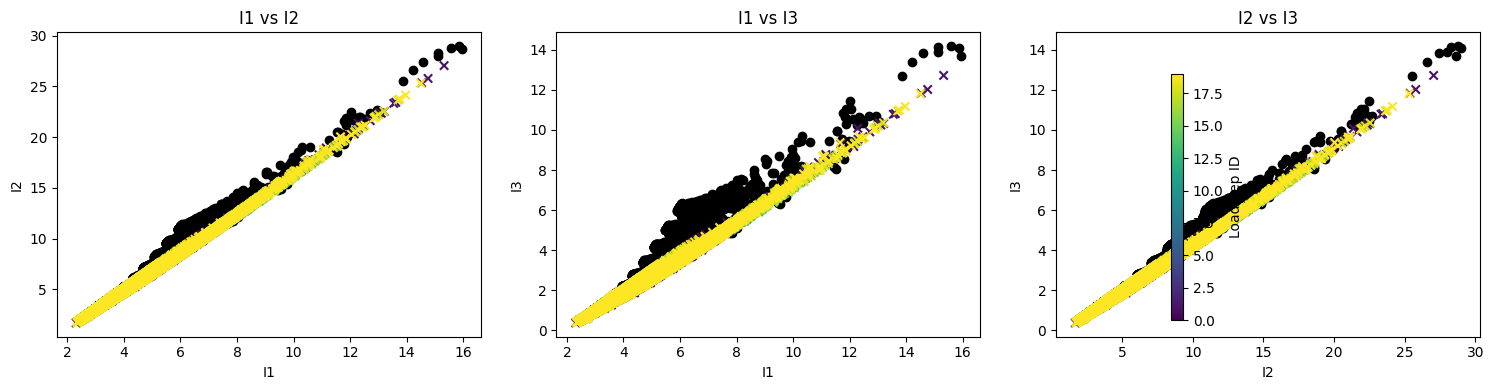

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# --- build a loadstep id for each test point ---
# lengths of each loadstep's invariants
sizes = [inv.shape[0] for inv in invariants_list]   # list of lengths
loadstep_ids = np.concatenate([
    np.full(s, i) for i, s in enumerate(sizes)
])

# color map
cmap = plt.cm.viridis

I1_train, I2_train, I3_train = invariants_train[:,0], invariants_train[:,1], invariants_train[:,2]
I1_test,  I2_test,  I3_test  = invariants_test[:,0], invariants_test[:,1], invariants_test[:,2]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. I1 vs I2
axes[0].scatter(I1_train, I2_train, color="black", marker='o', label='Train')
sc0 = axes[0].scatter(I1_test, I2_test, c=loadstep_ids, cmap=cmap, marker='x')
axes[0].set_xlabel("I1"); axes[0].set_ylabel("I2"); axes[0].set_title("I1 vs I2")

# 2. I1 vs I3
axes[1].scatter(I1_train, I3_train, color="black", marker='o', label='Train')
sc1 = axes[1].scatter(I1_test, I3_test, c=loadstep_ids, cmap=cmap, marker='x')
axes[1].set_xlabel("I1"); axes[1].set_ylabel("I3"); axes[1].set_title("I1 vs I3")

# 3. I2 vs I3
axes[2].scatter(I2_train, I3_train, color="black", marker='o', label='Train')
sc2 = axes[2].scatter(I2_test, I3_test, c=loadstep_ids, cmap=cmap, marker='x')
axes[2].set_xlabel("I2"); axes[2].set_ylabel("I3"); axes[2].set_title("I2 vs I3")

# Common colorbar for loadsteps
cbar = fig.colorbar(sc2, ax=axes, shrink=0.8)
cbar.set_label("Loadstep ID")

plt.tight_layout()
plt.show()


In [48]:
# sort loadsteps numerically, not as strings
loadsteps = sorted(dataset.loadsteps, key=int)

print("Sorted loadsteps:", loadsteps)

F_list = []
invariants_list = []
sigma_list = []
coeffs_list = []
piola_list = []
step = 15
# load each loadstep in sorted order
for ls in loadsteps[step:step+1]:
    data = dataset[ls]
    F_list.append(data["F"])
    invariants_list.append(data["invariants"])
    sigma_list.append(data["sigma"])
    coeffs_list.append(data["coeffs"])
    piola_list.append(data["P"])

# concatenate
F_test = jnp.concat(F_list)
invariants_test = jnp.concat(invariants_list)
sigma_test = jnp.concat(sigma_list)
coeffs_test = jnp.concat(coeffs_list)
piola_test = jnp.concat(piola_list)


Sorted loadsteps: ['5', '10', '15', '20', '25', '30', '35', '40', '45', '50', '55', '60', '65', '70', '75', '80', '85', '90', '95', '100']


/tmp/ipykernel_7871/971873103.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


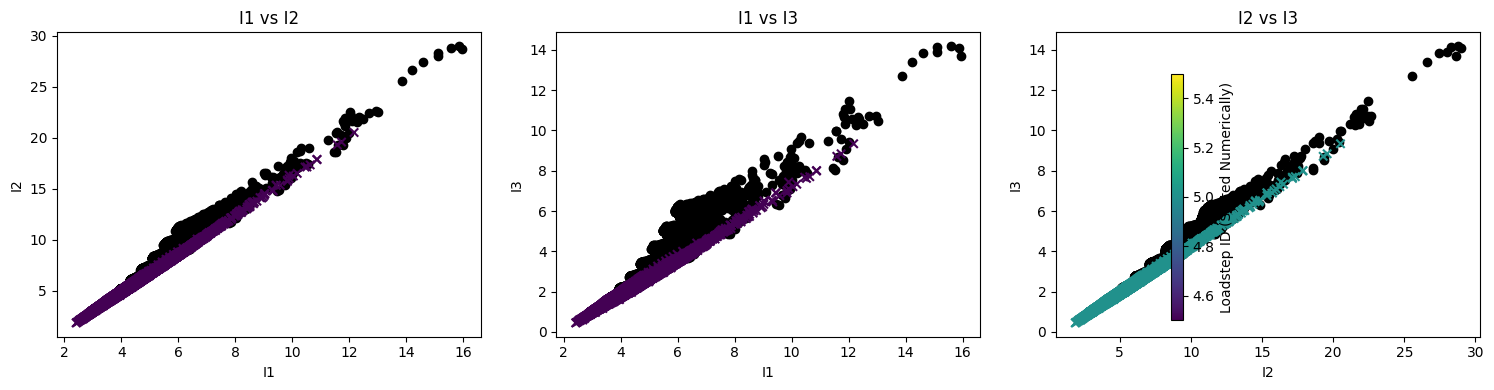

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# build loadstep ID per point (0,1,2,...)
sizes = [inv.shape[0] for inv in invariants_list]
loadstep_ids = np.concatenate([
    np.full(s, int(loadsteps[i])) for i, s in enumerate(sizes)
])
# loadstep_ids = [int(loadstep) for loadstep in loadsteps] 

cmap = plt.cm.viridis

# extract invariants
I1_test = invariants_test[:,0]
I2_test = invariants_test[:,1]
I3_test = invariants_test[:,2]

I1_train = invariants_train[:,0]
I2_train = invariants_train[:,1]
I3_train = invariants_train[:,2]

# plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. I1 vs I2
axes[0].scatter(I1_train, I2_train, color="black", marker='o', label="Train")
sc0 = axes[0].scatter(I1_test, I2_test, c=loadstep_ids, cmap=cmap, marker='x')
axes[0].set_xlabel("I1"); axes[0].set_ylabel("I2"); axes[0].set_title("I1 vs I2")

# 2. I1 vs I3
axes[1].scatter(I1_train, I3_train, color="black", marker='o', label="Train")
sc1 = axes[1].scatter(I1_test, I3_test, c=loadstep_ids, cmap=cmap, marker='x')
axes[1].set_xlabel("I1"); axes[1].set_ylabel("I3"); axes[1].set_title("I1 vs I3")

# 3. I2 vs I3
axes[2].scatter(I2_train, I3_train, color="black", marker='o', label="Train")
sc2 = axes[2].scatter(I2_test, I3_test, c=loadstep_ids, cmap=cmap, marker='x')
axes[2].set_xlabel("I2"); axes[2].set_ylabel("I3"); axes[2].set_title("I2 vs I3")

# shared colorbar
cbar = fig.colorbar(sc2, ax=axes, shrink=0.8)
cbar.set_label("Loadstep ID (Sorted Numerically)")

plt.tight_layout()
plt.show()


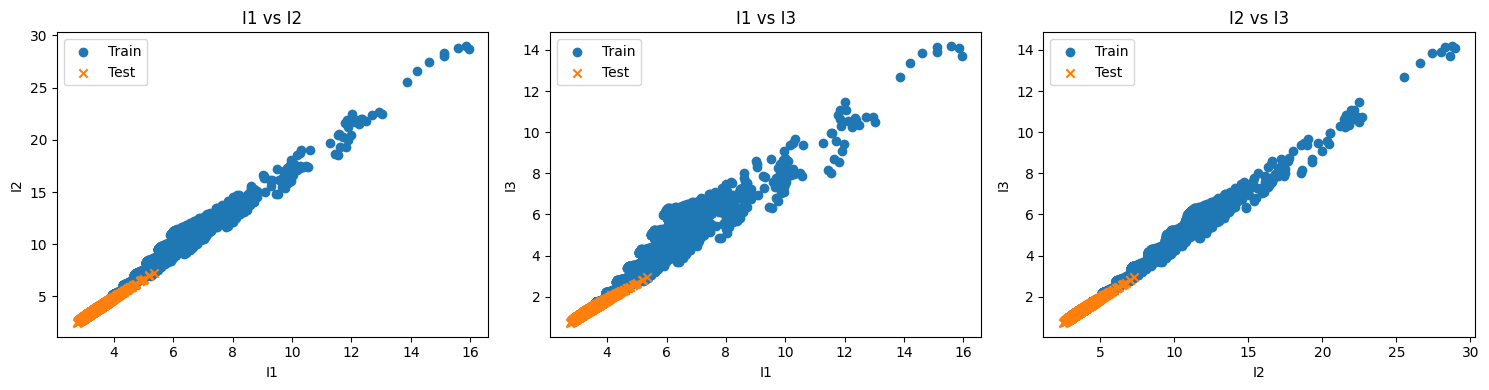

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Try loading user's arrays; create placeholders if missing
# I1_train, I2_train, I3_train = inv_train[:,2]**(-1/3) * inv_train[:,0], inv_train[:,2]**(-2/3) * inv_train[:,1], inv_train[:,2]
# I1_test, I2_test, I3_test = inv_test[:,2]**(-1/3) *  inv_test[:,0], inv_test[:,2]**(-2/3) * inv_test[:,1], inv_test[:,2]

I1_train, I2_train, I3_train =  invariants_train[:,0], invariants_train[:,1], invariants_train[:,2]
I1_test, I2_test, I3_test = invariants_test[:,0], invariants_test[:,1], invariants_test[:,2]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. I1 vs I2
axes[0].scatter(I1_train, I2_train, marker='o', label='Train')
axes[0].scatter(I1_test, I2_test, marker='x', label='Test')
axes[0].set_xlabel("I1")
axes[0].set_ylabel("I2")
axes[0].set_title("I1 vs I2")
axes[0].legend()

# 2. I1 vs I3
axes[1].scatter(I1_train, I3_train, marker='o', label='Train')
axes[1].scatter(I1_test, I3_test, marker='x', label='Test')
axes[1].set_xlabel("I1")
axes[1].set_ylabel("I3")
axes[1].set_title("I1 vs I3")
axes[1].legend()

# 3. I2 vs I3
axes[2].scatter(I2_train, I3_train, marker='o', label='Train')
axes[2].scatter(I2_test, I3_test, marker='x', label='Test')
axes[2].set_xlabel("I2")
axes[2].set_ylabel("I3")
axes[2].set_title("I2 vs I3")
axes[2].legend()

plt.tight_layout()
plt.show()
